# Retail Performance Analytics

## 1. Data Profiling

### Project Overview

This notebook documents the initial profiling of the UCI Online Retail dataset before data cleaning and transformation.

The purpose of this stage is to understand the dataset's structure, data types, completeness, uniqueness, duplication, and potential data-quality issues.

### Dataset

- **Source:** UCI Machine Learning Repository
- **Dataset:** Online Retail
- **Business:** UK-based online retailer
- **Period:** December 2010 – December 2011

### Profiling Objectives

- Inspect the dataset structure and dimensions
- Examine data types
- Identify missing values
- Identify duplicate records
- Examine descriptive statistics
- Assess unique values across variables
- Identify potential data-quality issues requiring further investigation

## 1.1 Environment and Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Load Dataset

In [3]:
file_path = "../data/raw/online_retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1.3 Dataset Dimensions

In [4]:
df.shape

(541909, 8)

## 1.4 Initial Data Preview

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1.5 Dataset Structure and Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 1.6 Missing Values

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 1.7 Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(5268)

## 1.8 Descriptive Statistics

In [9]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


## 1.9 Unique Values

In [10]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [13]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [14]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [15]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [16]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

## 1.10 Initial Data Quality Findings

In [17]:
quality_summary = pd.DataFrame({
    "Issue": [
        "Missing descriptions",
        "Missing customer IDs",
        "Duplicate rows",
        "Negative quantities",
        "Negative unit prices"
    ],
    "Count": [
        df["Description"].isna().sum(),
        df["CustomerID"].isna().sum(),
        df.duplicated().sum(),
        (df["Quantity"] < 0).sum(),
        (df["UnitPrice"] < 0).sum()
    ]
})

quality_summary

,Issue,Count
0,Missing descriptions,1454
1,Missing customer IDs,135080
2,Duplicate rows,5268
3,Negative quantities,10624
4,Negative unit prices,2


## 1.11 Transaction Characteristics

In [18]:
df["Quantity"].value_counts().head(10)

Quantity
1     148227
2      81829
12     61063
6      40868
4      38484
3      37121
24     24021
10     22288
8      13129
5      11757
Name: count, dtype: int64

In [19]:
df["UnitPrice"].value_counts().head(10)

UnitPrice
1.25    50496
1.65    38181
0.85    28497
2.95    27768
0.42    24533
4.95    19040
3.75    18600
2.10    17697
2.46    17091
2.08    17005
Name: count, dtype: int64

In [20]:
(df["Quantity"] < 0).value_counts()

Quantity
False    531285
True      10624
Name: count, dtype: int64

In [21]:
(df["UnitPrice"] <= 0).value_counts()

UnitPrice
False    539392
True       2517
Name: count, dtype: int64

In [22]:
df.loc[df["UnitPrice"] <= 0, ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


In [23]:
df.loc[df["Quantity"] < 0, ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,17897.0,United Kingdom


In [24]:
df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64

In [25]:
df.loc[df["UnitPrice"] < 0, ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


In [26]:
df.loc[df["Description"].isna(), ["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "CustomerID", "Country"]].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,56,0.0,NaN,United Kingdom
1970,536545,21134,1,0.0,NaN,United Kingdom
1971,536546,22145,1,0.0,NaN,United Kingdom
1972,536547,37509,1,0.0,NaN,United Kingdom
1987,536549,85226A,1,0.0,NaN,United Kingdom
1988,536550,85044,1,0.0,NaN,United Kingdom
2024,536552,20950,1,0.0,NaN,United Kingdom
2025,536553,37461,3,0.0,NaN,United Kingdom
2026,536554,84670,23,0.0,NaN,United Kingdom
2406,536589,21777,-10,0.0,NaN,United Kingdom


# 2. Data Cleaning

### 2.1 Cleaning Strategy

The raw dataset contains missing values, duplicate records, cancellation transactions, non-standard financial adjustments, and records with zero unit prices. Cleaning decisions will be based on the analytical objectives of the project while preserving legitimate business transactions such as cancellations for separate analysis.

In [27]:
df_clean = df.copy()

df_clean.shape

(541909, 8)

In [28]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [29]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [30]:
df_clean["Description"].isna().sum(), df_clean["CustomerID"].isna().sum()

(np.int64(1454), np.int64(135080))

In [31]:
df_clean[df_clean["CustomerID"].isna()]["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    134697
True        383
Name: count, dtype: int64

In [32]:
df_clean["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64

In [33]:
df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")]["Quantity"].describe()

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [34]:
df_clean.loc[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C"),
    "UnitPrice"
].describe()

count    532621.000000
mean          3.847621
std          41.758023
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       13541.330000
Name: UnitPrice, dtype: float64

In [35]:
df_clean.loc[
    (df_clean["UnitPrice"] <= 0) |
    (df_clean["Quantity"] <= 0),
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].shape

(11805, 5)

In [36]:
df_clean.loc[
    (df_clean["UnitPrice"] <= 0) &
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C")),
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].shape

(2517, 6)

In [37]:
df_clean.loc[
    (df_clean["UnitPrice"] <= 0) &
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C"))
].groupby("UnitPrice").size()

UnitPrice
-11062.06       2
 0.00        2515
dtype: int64

In [38]:
df_clean.loc[
    (df_clean["UnitPrice"] == 0) &
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C")),
    "Description"
].value_counts(dropna=False).head(15)

Description
NaN                              1454
check                             159
?                                  47
damages                            45
damaged                            43
found                              25
sold as set on dotcom              20
adjustment                         16
Damaged                            14
Unsaleable, destroyed.              9
thrown away                         9
FRENCH BLUE METAL DOOR SIGN 1       9
FRENCH BLUE METAL DOOR SIGN 8       8
amazon                              8
Found                               8
Name: count, dtype: int64

In [39]:
df_clean.loc[
    (df_clean["UnitPrice"] == 0) &
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C")),
    "Description"
].value_counts(dropna=False).head(30)

Description
NaN                                1454
check                               159
?                                    47
damages                              45
damaged                              43
found                                25
sold as set on dotcom                20
adjustment                           16
Damaged                              14
Unsaleable, destroyed.                9
thrown away                           9
FRENCH BLUE METAL DOOR SIGN 1         9
FRENCH BLUE METAL DOOR SIGN 8         8
amazon                                8
Found                                 8
FRENCH BLUE METAL DOOR SIGN 4         7
Amazon                                7
FRENCH BLUE METAL DOOR SIGN 3         7
RECIPE BOX PANTRY YELLOW DESIGN       7
OWL DOORSTOP                          7
FRENCH BLUE METAL DOOR SIGN No        7
??                                    7
dotcom                                6
MINT KITCHEN SCALES                   6
Manual                      

In [40]:
df_clean = df_clean[
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C")) &
    (df_clean["UnitPrice"] > 0)
].copy()

df_clean.shape

(530104, 8)

In [41]:
df_clean.duplicated().sum()

np.int64(5226)

In [42]:
df_clean = df_clean.drop_duplicates().copy()

df_clean.shape

(524878, 8)

In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.0+ MB


In [44]:
cleaning_check = pd.DataFrame({
    "Check": [
        "Rows",
        "Duplicate rows",
        "Missing descriptions",
        "Missing Customer IDs",
        "Non-positive quantities",
        "Non-positive unit prices"
    ],
    "Result": [
        len(df_clean),
        df_clean.duplicated().sum(),
        df_clean["Description"].isna().sum(),
        df_clean["CustomerID"].isna().sum(),
        (df_clean["Quantity"] <= 0).sum(),
        (df_clean["UnitPrice"] <= 0).sum()
    ]
})

cleaning_check

,Check,Result
0,Rows,524878
1,Duplicate rows,0
2,Missing descriptions,0
3,Missing Customer IDs,132186
4,Non-positive quantities,0
5,Non-positive unit prices,0


In [45]:
df_clean = df_clean.reset_index(drop=True)

df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [46]:
df_clean.shape

(524878, 8)

In [47]:
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [48]:
df_clean.shape

(524878, 8)

In [49]:
import os

print(os.path.exists("../data/processed/online_retail_clean.csv"))

True


In [50]:
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [51]:
pd.read_csv("../data/processed/online_retail_clean.csv").shape

/var/folders/5v/q4hrv7sn5t56008mkbgk54cr0000gn/T/ipykernel_27198/3553544603.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("../data/processed/online_retail_clean.csv").shape


(524878, 8)

In [52]:
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)

In [53]:
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [54]:
pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    dtype={"InvoiceNo": str, "StockCode": str}
).shape

(524878, 8)

## 2.2 Feature Engineering

In [55]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [56]:
df_clean["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [57]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["Year"] = df_clean["InvoiceDate"].dt.year

df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean["MonthName"] = df_clean["InvoiceDate"].dt.month_name()

df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()

df_clean[["InvoiceDate", "Year", "Month", "MonthName", "DayOfWeek"]].head()

,InvoiceDate,Year,Month,MonthName,DayOfWeek
0,2010-12-01 08:26:00,2010,12,December,Wednesday
1,2010-12-01 08:26:00,2010,12,December,Wednesday
2,2010-12-01 08:26:00,2010,12,December,Wednesday
3,2010-12-01 08:26:00,2010,12,December,Wednesday
4,2010-12-01 08:26:00,2010,12,December,Wednesday


In [58]:
df_clean["Quarter"] = df_clean["InvoiceDate"].dt.quarter

df_clean[["InvoiceDate", "Year", "Month", "Quarter", "DayOfWeek"]].head()

,InvoiceDate,Year,Month,Quarter,DayOfWeek
0,2010-12-01 08:26:00,2010,12,4,Wednesday
1,2010-12-01 08:26:00,2010,12,4,Wednesday
2,2010-12-01 08:26:00,2010,12,4,Wednesday
3,2010-12-01 08:26:00,2010,12,4,Wednesday
4,2010-12-01 08:26:00,2010,12,4,Wednesday


In [59]:
df_clean[["Revenue", "Year", "Month", "Quarter"]].head()

,Revenue,Year,Month,Quarter
0,15.30,2010,12,4
1,20.34,2010,12,4
2,22.00,2010,12,4
3,20.34,2010,12,4
4,20.34,2010,12,4


In [60]:
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.


In [61]:
df_clean.shape

(524878, 14)

In [62]:
final_check = {
    "Rows": len(df_clean),
    "Columns": len(df_clean.columns),
    "Duplicate rows": df_clean.duplicated().sum(),
    "Missing descriptions": df_clean["Description"].isna().sum(),
    "Missing Customer IDs": df_clean["CustomerID"].isna().sum(),
    "Non-positive quantities": (df_clean["Quantity"] <= 0).sum(),
    "Non-positive unit prices": (df_clean["UnitPrice"] <= 0).sum(),
    "Missing revenue": df_clean["Revenue"].isna().sum()
}

pd.Series(final_check)

Rows                        524878
Columns                         14
Duplicate rows                   0
Missing descriptions             0
Missing Customer IDs        132186
Non-positive quantities          0
Non-positive unit prices         0
Missing revenue                  0
dtype: int64

# 3. Exploratory Data Analysis

In [63]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,524878.0,10.6166,1.0,1.0,4.0,11.0,80995.0,156.280031
InvoiceDate,524878,2011-07-04 15:30:16.317049088,2010-12-01 08:26:00,2011-03-28 12:13:00,2011-07-20 11:22:00,2011-10-19 11:41:00,2011-12-09 12:50:00,NaN
UnitPrice,524878.0,3.922573,0.001,1.25,2.08,4.13,13541.33,36.093028
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549
Revenue,524878.0,20.275399,0.001,3.9,9.92,17.7,168469.6,271.693566
Year,524878.0,2010.921904,2010.0,2011.0,2011.0,2011.0,2011.0,0.268323
Month,524878.0,7.552237,1.0,5.0,8.0,11.0,12.0,3.508164
Quarter,524878.0,2.834194,1.0,2.0,3.0,4.0,4.0,1.136716


In [64]:
monthly_sales = (
    df_clean.groupby(["Year", "Month"], as_index=False)["Revenue"]
    .sum()
)

monthly_sales

,Year,Month,Revenue
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491
5,2011,5,769296.610
6,2011,6,760547.010
7,2011,7,718076.121
8,2011,8,757841.380
9,2011,9,1056435.192


In [65]:
monthly_sales["Period"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Period")

monthly_sales

,Year,Month,Revenue,Period
0,2010,12,821452.730,2010-12-01
1,2011,1,689811.610,2011-01-01
2,2011,2,522545.560,2011-02-01
3,2011,3,716215.260,2011-03-01
4,2011,4,536968.491,2011-04-01
5,2011,5,769296.610,2011-05-01
6,2011,6,760547.010,2011-06-01
7,2011,7,718076.121,2011-07-01
8,2011,8,757841.380,2011-08-01
9,2011,9,1056435.192,2011-09-01


In [66]:
monthly_sales["Revenue"].pct_change() * 100

0           NaN
1    -16.025404
2    -24.248077
3     37.062740
4    -25.026941
5     43.266620
6     -1.137351
7     -5.584256
8      5.537750
9     39.400568
10     8.976276
11    30.627478
12   -57.589972
Name: Revenue, dtype: float64

In [67]:
monthly_sales.loc[
    monthly_sales["Revenue"].idxmax()
]

Year                      2011
Month                       11
Revenue             1503866.78
Period     2011-11-01 00:00:00
Name: 11, dtype: object

In [68]:
monthly_sales.loc[
    monthly_sales["Revenue"].idxmin()
]

Year                      2011
Month                        2
Revenue              522545.56
Period     2011-02-01 00:00:00
Name: 2, dtype: object

In [69]:
monthly_sales["Revenue"].sum()

np.float64(10642110.804)

In [70]:
monthly_sales["Revenue"].mean()

np.float64(818623.9079999999)

In [71]:
country_sales = (
    df_clean.groupby("Country", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

country_sales.head(10)

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


In [72]:
country_sales["Revenue"].head(10).sum()

np.float64(10345278.864)

In [73]:
country_sales["Revenue"].sum()

np.float64(10642110.804)

In [74]:
customer_sales = (
    df_clean.dropna(subset=["CustomerID"])
    .groupby("CustomerID", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

customer_sales.head(10)

,CustomerID,Revenue
1689,14646,280206.02
4201,18102,259657.30
3728,17450,194390.79
3008,16446,168472.50
1879,14911,143711.17
55,12415,124914.53
1333,14156,117210.08
3771,17511,91062.38
2702,16029,80850.84
0,12346,77183.60


In [75]:
customer_sales["Revenue"].describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Revenue, dtype: float64

In [76]:
customer_sales["Revenue"].describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Revenue, dtype: float64

In [77]:
product_sales = (
    df_clean.groupby(["StockCode", "Description"], as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

product_sales.head(10)

,StockCode,Description,Revenue
4150,DOT,DOTCOM POSTAGE,206248.77
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
2877,47566,PARTY BUNTING,99445.23
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
4153,POST,POSTAGE,78101.88
4151,M,Manual,77750.27
2029,23084,RABBIT NIGHT LIGHT,66870.03


In [78]:
country_customers = (
    df_clean.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
)

country_customers.head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

In [79]:
product_quantity = (
    df_clean.groupby(["StockCode", "Description"], as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
)

product_quantity.head(10)

,StockCode,Description,Quantity
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
3128,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3619,85099B,JUMBO BAG RED RETROSPOT,48371
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580
1129,22197,POPCORN HOLDER,36749
448,21212,PACK OF 72 RETROSPOT CAKE CASES,36396
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,36362
2029,23084,RABBIT NIGHT LIGHT,30739
1405,22492,MINI PAINT SET VINTAGE,26633


In [80]:
invoice_summary = (
    df_clean.groupby("InvoiceNo")
    .agg(
        Revenue=("Revenue", "sum"),
        Items=("Quantity", "sum"),
        Products=("StockCode", "nunique"),
        CustomerID=("CustomerID", "first")
    )
    .reset_index()
)

invoice_summary.describe()

,Revenue,Items,Products,CustomerID
count,19960.000000,19960.000000,19960.000000,18532.0
mean,533.171884,279.179359,26.032164,15266.378211
std,1780.412288,955.011810,46.982195,1734.116296
min,0.380000,1.000000,1.000000,12346.0
25%,151.695000,69.000000,6.000000,13776.25
50%,303.300000,150.000000,15.000000,15178.5
75%,493.462500,296.000000,29.000000,16779.0
max,168469.600000,80995.000000,1110.000000,18287.0


In [81]:
daily_sales = (
    df_clean.groupby(df_clean["InvoiceDate"].dt.date)["Revenue"]
    .sum()
    .reset_index(name="Revenue")
)

daily_sales["InvoiceDate"] = pd.to_datetime(daily_sales["InvoiceDate"])

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01,58776.79
1,2010-12-02,47629.42
2,2010-12-03,46898.63
3,2010-12-05,31364.63
4,2010-12-06,54624.15


In [82]:
daily_sales["Revenue"].describe()

count       305.000000
mean      34892.166570
std       21098.282521
min        3439.670000
25%       22345.930000
50%       29526.290000
75%       45277.920000
max      200900.980000
Name: Revenue, dtype: float64

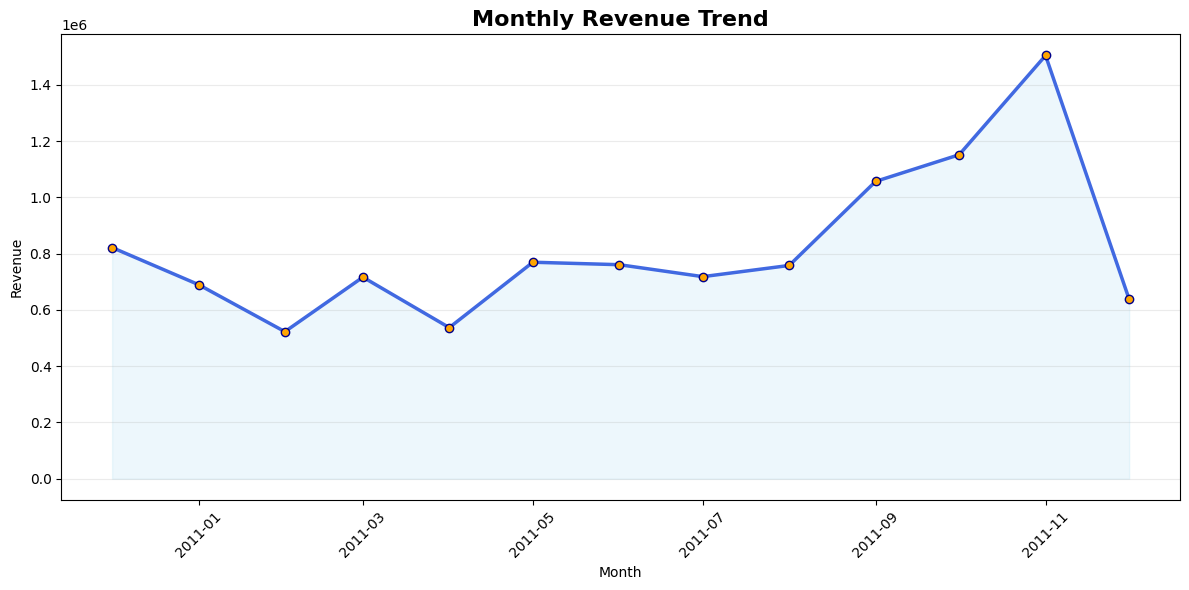

In [83]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Period"],
    monthly_sales["Revenue"],
    marker="o",
    linewidth=2.5,
    color="royalblue",
    markerfacecolor="orange",
    markeredgecolor="darkblue"
)

plt.fill_between(
    monthly_sales["Period"],
    monthly_sales["Revenue"],
    alpha=0.15,
    color="skyblue"
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig("../visuals/monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

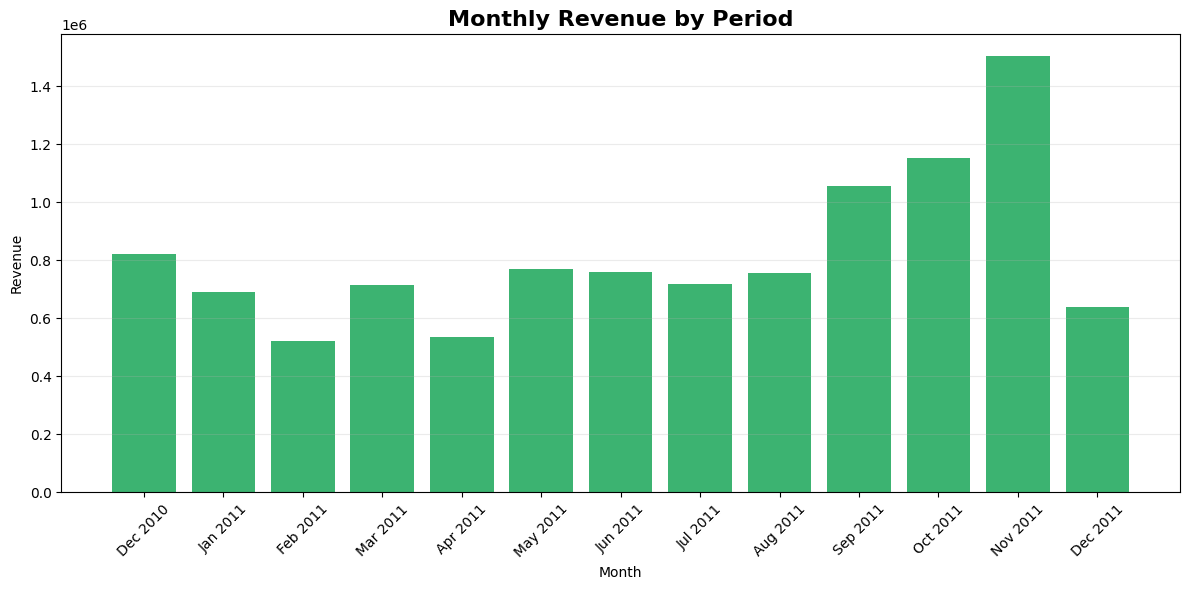

In [84]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_sales["Period"].dt.strftime("%b %Y"),
    monthly_sales["Revenue"],
    color="mediumseagreen"
)

plt.title("Monthly Revenue by Period", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../visuals/monthly_revenue_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Revenue Performance

### Business Question

How did revenue perform over the analysis period, and which months experienced the strongest growth and decline?

In [85]:
monthly_performance = monthly_sales.copy()

monthly_performance["MoM_Growth_%"] = (
    monthly_performance["Revenue"].pct_change() * 100
)

monthly_performance

,Year,Month,Revenue,Period,MoM_Growth_%
0,2010,12,821452.730,2010-12-01,NaN
1,2011,1,689811.610,2011-01-01,-16.025404
2,2011,2,522545.560,2011-02-01,-24.248077
3,2011,3,716215.260,2011-03-01,37.062740
4,2011,4,536968.491,2011-04-01,-25.026941
5,2011,5,769296.610,2011-05-01,43.266620
6,2011,6,760547.010,2011-06-01,-1.137351
7,2011,7,718076.121,2011-07-01,-5.584256
8,2011,8,757841.380,2011-08-01,5.537750
9,2011,9,1056435.192,2011-09-01,39.400568


In [86]:
strongest_growth = monthly_performance.loc[
    monthly_performance["MoM_Growth_%"].idxmax()
]

strongest_decline = monthly_performance.loc[
    monthly_performance["MoM_Growth_%"].idxmin()
]

strongest_growth, strongest_decline

(Year                           2011
 Month                             5
 Revenue                   769296.61
 Period          2011-05-01 00:00:00
 MoM_Growth_%               43.26662
 Name: 5, dtype: object,
 Year                           2011
 Month                            12
 Revenue                   637790.33
 Period          2011-12-01 00:00:00
 MoM_Growth_%             -57.589972
 Name: 12, dtype: object)

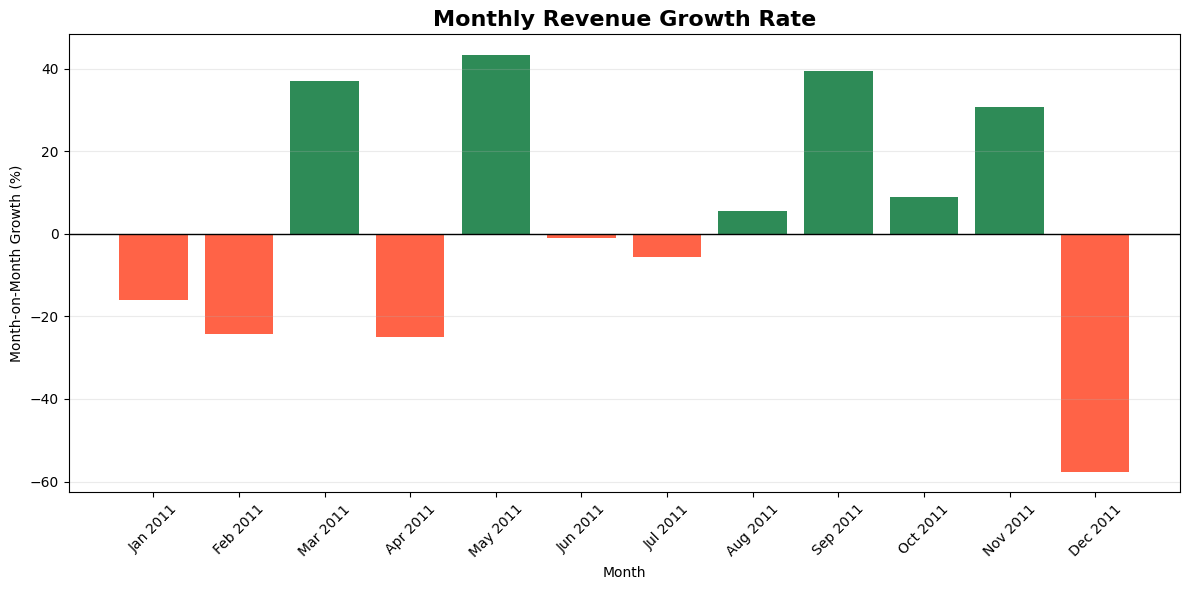

In [87]:
plt.figure(figsize=(12, 6))

growth_colors = [
    "seagreen" if value >= 0 else "tomato"
    for value in monthly_performance["MoM_Growth_%"].fillna(0)
]

plt.bar(
    monthly_performance["Period"].dt.strftime("%b %Y"),
    monthly_performance["MoM_Growth_%"],
    color=growth_colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Revenue Growth Rate", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Month-on-Month Growth (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../visuals/monthly_revenue_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Question

Which countries generate the most revenue, and how concentrated is revenue geographically?

In [88]:
country_analysis = country_sales.copy()

country_analysis["Revenue_Share_%"] = (
    country_analysis["Revenue"] /
    country_analysis["Revenue"].sum()
) * 100

country_analysis.head(10)

,Country,Revenue,Revenue_Share_%
36,United Kingdom,9001744.094,84.586078
24,Netherlands,285446.340,2.682234
10,EIRE,283140.520,2.660567
14,Germany,228678.400,2.148807
13,France,209625.370,1.969772
0,Australia,138453.810,1.301000
31,Spain,61558.560,0.578443
33,Switzerland,57067.600,0.536243
3,Belgium,41196.340,0.387107
32,Sweden,38367.830,0.360528


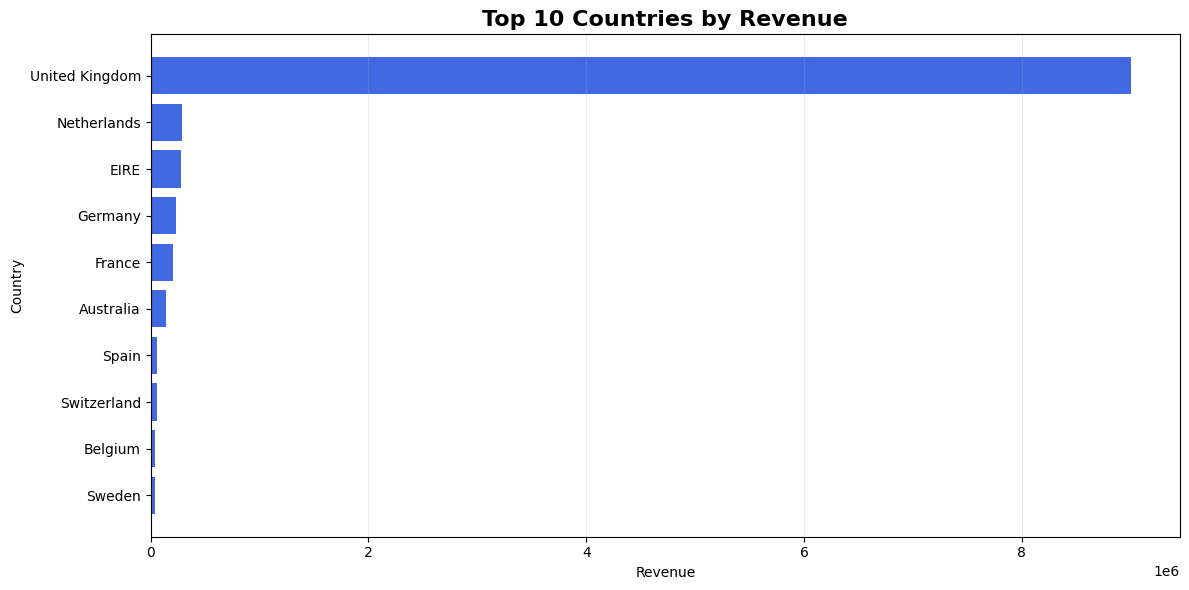

In [89]:
plt.figure(figsize=(12, 6))

top_countries = country_analysis.head(10).sort_values("Revenue")

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"],
    color="royalblue"
)

plt.title("Top 10 Countries by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../visuals/top_10_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

Revenue is highly concentrated geographically. The United Kingdom generates 84.6% of total revenue, while the Netherlands is the second-largest market at only 2.7%. The top 10 countries account for approximately 97.2% of total revenue.

This indicates that the business has a very strong core market in the UK but remains heavily dependent on a single geography. The relatively small contribution from other countries suggests potential opportunities to strengthen international markets and reduce geographic concentration risk.

### Business Implication

Management should protect the UK customer base while evaluating the growth potential of established international markets. Markets such as the Netherlands, Ireland, Germany and France could be prioritised for further analysis to determine whether customer acquisition, product mix or order frequency could be improved.

In [90]:
international_sales = country_analysis[
    country_analysis["Country"] != "United Kingdom"
].copy()

international_sales["Revenue_Share_%"] = (
    international_sales["Revenue"] /
    country_analysis["Revenue"].sum()
) * 100

international_sales.head(10)

,Country,Revenue,Revenue_Share_%
24,Netherlands,285446.34,2.682234
10,EIRE,283140.52,2.660567
14,Germany,228678.40,2.148807
13,France,209625.37,1.969772
0,Australia,138453.81,1.301000
31,Spain,61558.56,0.578443
33,Switzerland,57067.60,0.536243
3,Belgium,41196.34,0.387107
32,Sweden,38367.83,0.360528
20,Japan,37416.37,0.351588


In [91]:
international_sales["Revenue"].sum()

np.float64(1640366.71)

### Key Insight

The United Kingdom generates 84.6% of total revenue, while all international markets combined contribute £1.64M, representing approximately 15.4% of total revenue.

International revenue is concentrated within a small number of markets. The Netherlands and EIRE are the strongest international markets, contributing approximately 2.7% and 2.7% of total revenue respectively, followed by Germany at 2.1% and France at 2.0%.

### Business Implication

The business has a strong and established UK market but significant geographic dependence. International markets already generate meaningful revenue, but their relatively small individual contributions suggest an opportunity to identify markets where customer acquisition and sales growth could be expanded.

The next analysis therefore examines whether the strongest international markets are generating revenue through a broad customer base or a smaller number of high-value customers.

In [92]:
country_customer_analysis = (
    df_clean.dropna(subset=["CustomerID"])
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

country_customer_analysis["Revenue_per_Customer"] = (
    country_customer_analysis["Revenue"] /
    country_customer_analysis["Customers"]
)

country_customer_analysis = country_customer_analysis.sort_values(
    "Revenue",
    ascending=False
)

country_customer_analysis.head(10)

,Country,Revenue,Customers,Orders,Revenue_per_Customer
35,United Kingdom,7285024.644,3920,16646,1858.424654
23,Netherlands,285446.340,9,94,31716.260000
10,EIRE,265262.460,3,260,88420.820000
14,Germany,228678.400,94,457,2432.748936
13,France,208934.310,87,389,2401.543793
0,Australia,138453.810,9,57,15383.756667
30,Spain,61558.560,30,90,2051.952000
32,Switzerland,56443.950,21,51,2687.807143
3,Belgium,41196.340,25,98,1647.853600
31,Sweden,38367.830,8,36,4795.978750


### Key Insight

International markets differ substantially in their revenue composition.

Germany and France combine relatively large customer bases with substantial revenue, making them stronger candidates for scalable international growth. In contrast, markets such as the Netherlands and Australia generate high revenue per customer but rely on only nine customers each, indicating greater customer concentration.

EIRE records the highest revenue per customer among the major international markets; however, this is based on only three customers and should therefore not be interpreted as evidence of a broadly established market.

### Business Implication

International expansion should not be prioritised solely on total revenue or revenue per customer. Markets should also be assessed according to customer-base depth and concentration.

Germany and France appear to offer the strongest foundations for scalable international growth, while high-value but low-customer markets such as the Netherlands, Australia and EIRE warrant further investigation to determine whether their performance reflects repeatable demand or a small number of exceptional customers.

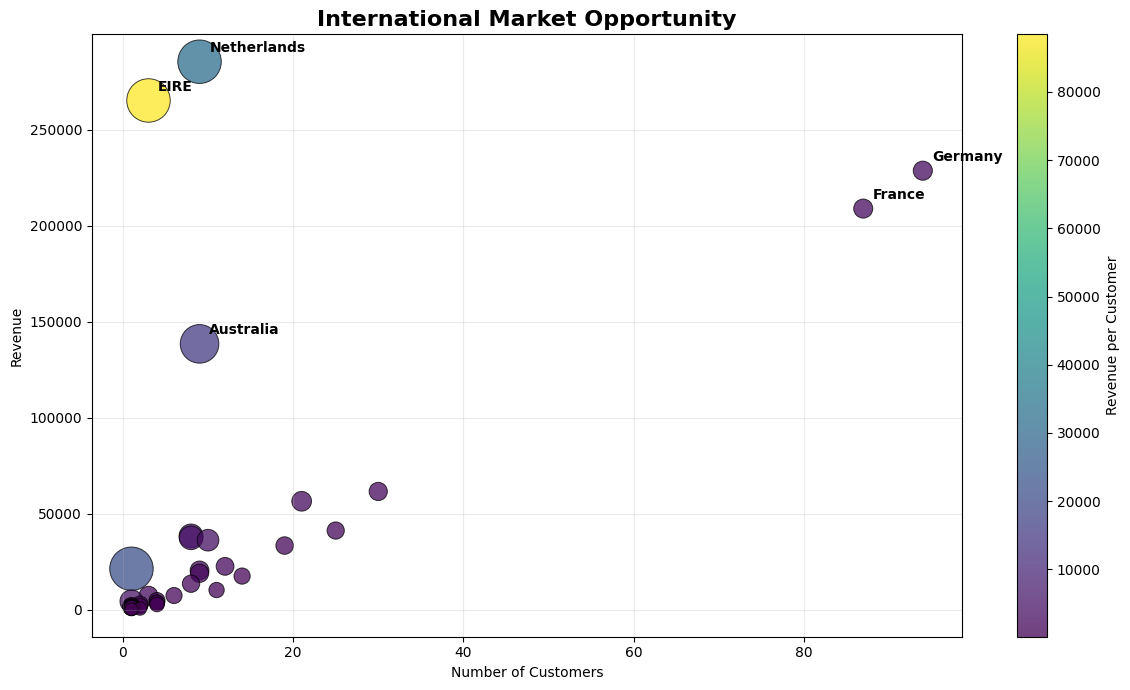

In [94]:
plt.figure(figsize=(12, 7))

# Keep bubble sizes readable
bubble_sizes = (
    international_markets["Revenue_per_Customer"]
    .clip(upper=20000)
    / 20000
    * 900
) + 80

scatter = plt.scatter(
    international_markets["Customers"],
    international_markets["Revenue"],
    s=bubble_sizes,
    c=international_markets["Revenue_per_Customer"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7
)

# Highlight the main markets
priority_markets = ["Germany", "France", "Netherlands", "EIRE", "Australia"]

for _, row in international_markets[
    international_markets["Country"].isin(priority_markets)
].iterrows():

    plt.annotate(
        row["Country"],
        (row["Customers"], row["Revenue"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

plt.colorbar(
    scatter,
    label="Revenue per Customer"
)

plt.title(
    "International Market Opportunity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Revenue")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../visuals/international_market_opportunity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insight

The international market analysis reveals two distinct growth patterns. Germany and France combine relatively large customer bases with strong revenue, suggesting a more scalable foundation for international growth. In contrast, the Netherlands, EIRE and Australia generate substantial revenue from very small customer bases, indicating that their performance is more concentrated among a limited number of customers.

### Business Implication

Germany and France should be considered priority markets for scalable international expansion because their existing revenue is supported by a broader customer base. High-value but low-customer markets should instead be investigated for customer concentration and repeat-purchase behaviour before additional investment decisions are made.

### Business Question

How concentrated is revenue among customers, and how important are high-value customers to overall performance?

In [95]:
customer_analysis = (
    df_clean.dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Items=("Quantity", "sum")
    )
    .reset_index()
)

customer_analysis["Average_Order_Value"] = (
    customer_analysis["Revenue"] /
    customer_analysis["Orders"]
)

customer_analysis = customer_analysis.sort_values(
    "Revenue",
    ascending=False
)

customer_analysis.head(10)

,CustomerID,Revenue,Orders,Items,Average_Order_Value
1689,14646,280206.02,73,196915,3838.438630
4201,18102,259657.30,60,64124,4327.621667
3728,17450,194390.79,46,69973,4225.886739
3008,16446,168472.50,2,80997,84236.250000
1879,14911,143711.17,201,80240,714.980945
55,12415,124914.53,21,77374,5948.310952
1333,14156,117210.08,55,57768,2131.092364
3771,17511,91062.38,31,64549,2937.496129
2702,16029,80850.84,63,40108,1283.346667
0,12346,77183.60,1,74215,77183.600000


In [96]:
top_10_customer_revenue = customer_analysis.head(10)["Revenue"].sum()

total_customer_revenue = customer_analysis["Revenue"].sum()

top_10_share = (
    top_10_customer_revenue /
    total_customer_revenue
) * 100

top_10_customer_revenue, total_customer_revenue, top_10_share

(np.float64(1537659.2100000002),
 np.float64(8887208.894000001),
 np.float64(17.30193616848723))

### Key Insight

Customer revenue is moderately concentrated, with the top 10 customers contributing 17.3% of total customer-attributed revenue. The highest-value customer generated £280.2K, while several other customers exceeded £100K in revenue.

However, customer value is driven by different purchasing patterns. Some high-value customers generate substantial revenue through frequent orders, while others achieve high revenue through only one or two exceptionally large orders. This indicates that revenue concentration should be evaluated alongside order frequency and average order value.

### Business Implication

High-value customers represent an important source of revenue and should be prioritised for retention and relationship management. However, the business should distinguish between customers with sustained purchasing behaviour and customers whose value is driven by isolated large transactions.

This distinction can help management identify customers suitable for retention programmes, account management and targeted cross-selling while avoiding overestimating the long-term value of one-off large purchases.

In [97]:
customer_analysis["Cumulative_Revenue"] = (
    customer_analysis["Revenue"].cumsum()
)

customer_analysis["Cumulative_Revenue_Share_%"] = (
    customer_analysis["Cumulative_Revenue"] /
    customer_analysis["Revenue"].sum()
) * 100

customer_analysis["Customer_Rank"] = range(
    1, len(customer_analysis) + 1
)

customer_analysis.head(10)

,CustomerID,Revenue,Orders,Items,Average_Order_Value,Cumulative_Revenue,Cumulative_Revenue_Share_%,Customer_Rank
1689,14646,280206.02,73,196915,3838.438630,280206.02,3.152914,1
4201,18102,259657.30,60,64124,4327.621667,539863.32,6.074610,2
3728,17450,194390.79,46,69973,4225.886739,734254.11,8.261920,3
3008,16446,168472.50,2,80997,84236.250000,902726.61,10.157594,4
1879,14911,143711.17,201,80240,714.980945,1046437.78,11.774650,5
55,12415,124914.53,21,77374,5948.310952,1171352.31,13.180205,6
1333,14156,117210.08,55,57768,2131.092364,1288562.39,14.499067,7
3771,17511,91062.38,31,64549,2937.496129,1379624.77,15.523713,8
2702,16029,80850.84,63,40108,1283.346667,1460475.61,16.433457,9
0,12346,77183.60,1,74215,77183.600000,1537659.21,17.301936,10


In [98]:
customer_concentration = pd.DataFrame({
    "Customer Segment": [
        "Top 1%",
        "Top 5%",
        "Top 10%",
        "Top 20%"
    ],
    "Revenue Share (%)": [
        customer_analysis.iloc[
            max(0, int(len(customer_analysis) * 0.01) - 1)
        ]["Cumulative_Revenue_Share_%"],
        customer_analysis.iloc[
            max(0, int(len(customer_analysis) * 0.05) - 1)
        ]["Cumulative_Revenue_Share_%"],
        customer_analysis.iloc[
            max(0, int(len(customer_analysis) * 0.10) - 1)
        ]["Cumulative_Revenue_Share_%"],
        customer_analysis.iloc[
            max(0, int(len(customer_analysis) * 0.20) - 1)
        ]["Cumulative_Revenue_Share_%"]
    ]
})

customer_concentration

,Customer Segment,Revenue Share (%)
0,Top 1%,31.839912
1,Top 5%,50.389428
2,Top 10%,61.411110
3,Top 20%,74.660621


### Key Insight

Customer revenue is highly concentrated among a relatively small group of customers. The top 1% of customers account for 31.8% of revenue attributed to identifiable customers, while the top 5% account for 50.4%. By the time the top 20% of customers are considered, they generate 74.7% of customer-attributed revenue.

This indicates that a relatively small group of customers has a disproportionate impact on commercial performance.

It is important to note that this analysis is based on £8.89M of revenue associated with identifiable Customer IDs. Records without a Customer ID are excluded from customer-level concentration analysis.

### Business Implication

The business should treat high-value customer retention as a strategic priority because the loss of a relatively small number of major customers could have a material effect on revenue.

However, the concentration also creates an opportunity: the remaining customer base represents a substantial pool for retention, repeat-purchase and cross-selling initiatives. Customer segmentation should therefore distinguish high-value loyal customers from high-value one-off purchasers and lower-value customers with growth potential.

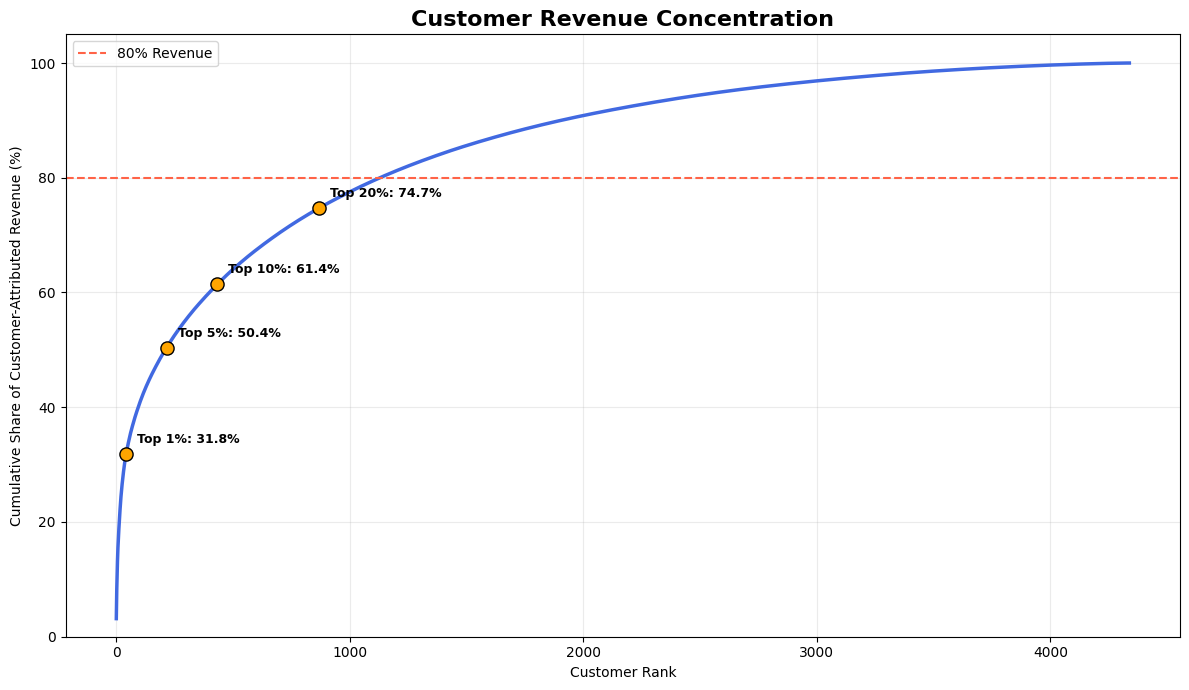

In [99]:
plt.figure(figsize=(12, 7))

plt.plot(
    customer_analysis["Customer_Rank"],
    customer_analysis["Cumulative_Revenue_Share_%"],
    color="royalblue",
    linewidth=2.5
)

plt.axhline(
    80,
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label="80% Revenue"
)

# Key concentration points
segments = {
    "Top 1%": 0.01,
    "Top 5%": 0.05,
    "Top 10%": 0.10,
    "Top 20%": 0.20
}

for label, proportion in segments.items():
    rank = max(1, int(len(customer_analysis) * proportion))
    value = customer_analysis.iloc[rank - 1]["Cumulative_Revenue_Share_%"]

    plt.scatter(
        rank,
        value,
        s=90,
        color="orange",
        edgecolors="black",
        zorder=5
    )

    plt.annotate(
        f"{label}: {value:.1f}%",
        (rank, value),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Customer Revenue Concentration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Rank")
plt.ylabel("Cumulative Share of Customer-Attributed Revenue (%)")
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../visuals/customer_revenue_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Question

Which products drive revenue, and do the products generating the most revenue also account for the highest sales volumes?

In [101]:
product_performance = (
    product_sales[["StockCode", "Description", "Revenue"]]
    .merge(
        product_quantity[["StockCode", "Quantity"]],
        on="StockCode",
        how="left"
    )
    .sort_values("Revenue", ascending=False)
)

product_performance["Revenue_Share_%"] = (
    product_performance["Revenue"] /
    product_performance["Revenue"].sum()
) * 100

product_performance.head(10)

,StockCode,Description,Revenue,Quantity,Revenue_Share_%
0,DOT,DOTCOM POSTAGE,206248.77,706,1.726105
1,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1.457524
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1.409930
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,0.872759
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,61,0.872759
5,47566,PARTY BUNTING,99445.23,18283,0.832262
6,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,0.788028
7,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,0.683759
8,POST,POSTAGE,78101.88,3150,0.653638
9,M,Manual,77750.27,6984,0.650695


In [102]:
top_10_product_revenue = product_performance.head(10)["Revenue"].sum()

total_product_revenue = product_performance["Revenue"].sum()

top_10_product_share = (
    top_10_product_revenue /
    total_product_revenue
) * 100

top_10_product_revenue, total_product_revenue, top_10_product_share

(np.float64(1188601.5),
 np.float64(11948795.434),
 np.float64(9.947458775784746))

In [103]:
product_performance = (
    df_clean
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

product_performance["Revenue_Share_%"] = (
    product_performance["Revenue"] /
    product_performance["Revenue"].sum()
) * 100

product_performance.head(10)

,StockCode,Description,Revenue,Quantity,Orders,Revenue_Share_%
4150,DOT,DOTCOM POSTAGE,206248.77,706,706,1.938044
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,1.636485
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1.583047
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189,0.979921
2877,47566,PARTY BUNTING,99445.23,18283,1685,0.934450
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,0.884785
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,0.767713
4153,POST,POSTAGE,78101.88,3150,1126,0.733895
4151,M,Manual,77750.27,6984,289,0.730591
2029,23084,RABBIT NIGHT LIGHT,66870.03,30739,994,0.628353


In [104]:
top_10_product_revenue = product_performance.head(10)["Revenue"].sum()

total_product_revenue = product_performance["Revenue"].sum()

top_10_product_share = (
    top_10_product_revenue /
    total_product_revenue
) * 100

top_10_product_revenue, total_product_revenue, top_10_product_share

(np.float64(1151187.29),
 np.float64(10642110.804),
 np.float64(10.817283443123978))

In [105]:
non_product_codes = ["DOT", "POST", "M"]

merchandise_performance = product_performance[
    ~product_performance["StockCode"].isin(non_product_codes)
].copy()

merchandise_performance["Revenue_Share_%"] = (
    merchandise_performance["Revenue"] /
    merchandise_performance["Revenue"].sum()
) * 100

merchandise_performance.head(10)

,StockCode,Description,Revenue,Quantity,Orders,Revenue_Share_%
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,1.694128
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1.638808
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189,1.014437
2877,47566,PARTY BUNTING,99445.23,18283,1685,0.967365
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,0.915951
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,0.794755
2029,23084,RABBIT NIGHT LIGHT,66870.03,30739,994,0.650486
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160,0.631085
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455,0.573225
3059,79321,CHILLI LIGHTS,54096.36,10302,661,0.526229


In [106]:
top_10_merchandise_revenue = (
    merchandise_performance.head(10)["Revenue"].sum()
)

total_merchandise_revenue = merchandise_performance["Revenue"].sum()

top_10_merchandise_share = (
    top_10_merchandise_revenue /
    total_merchandise_revenue
) * 100

top_10_merchandise_revenue, total_merchandise_revenue, top_10_merchandise_share

(np.float64(966985.94),
 np.float64(10280009.884),
 np.float64(9.406468971445591))

In [107]:
top_volume_products = (
    merchandise_performance
    .sort_values("Quantity", ascending=False)
    .head(10)
)

top_volume_products[
    ["StockCode", "Description", "Quantity", "Revenue", "Orders"]
]

,StockCode,Description,Quantity,Revenue,Orders
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
3128,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535
3619,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189
1129,22197,POPCORN HOLDER,36749,34288.67,803
448,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455
2029,23084,RABBIT NIGHT LIGHT,30739,66870.03,994
1405,22492,MINI PAINT SET VINTAGE,26633,16937.82,380


In [108]:
revenue_top_10 = set(
    merchandise_performance
    .nlargest(10, "Revenue")["StockCode"]
)

volume_top_10 = set(
    merchandise_performance
    .nlargest(10, "Quantity")["StockCode"]
)

overlap = revenue_top_10.intersection(volume_top_10)

len(overlap), overlap

(6, {'23084', '23166', '23843', '84879', '85099B', '85123A'})

### Key Insight

Product performance differs when measured by revenue and sales volume. Six of the ten highest-revenue merchandise products also appear among the ten highest-volume products, indicating that several products combine strong demand with meaningful revenue contribution.

However, the rankings are not identical. Some products generate high sales volumes without corresponding revenue, while others generate substantial revenue from fewer units or orders.

A notable exception is PAPER CRAFT, LITTLE BIRDIE, which recorded 80,995 units but only one order. This unusually large transaction should be treated as a potential bulk or exceptional purchase rather than representative of normal recurring demand.

### Business Implication

Product decisions should consider revenue, volume and order frequency together rather than relying on unit sales alone. Products that consistently perform strongly across these measures may warrant greater inventory and promotional attention, while unusual bulk transactions should be separated from recurring demand when forecasting future sales.